# Notebook 2 — 1D Multilayer FEM Verification

Because a closed-form analytical solution is not generally available for layered profiles, verification is done in stages:

1. **Single-layer reduction** — one layer with uniform u₀ must match the classical Terzaghi solution.
2. **Single-layer reduction with Boussinesq u₀** — must match the arbitrary-u₀ analytical solver built from the same initial field.
3. **Interface pore-pressure continuity** — with two contrasting layers, u must remain continuous across the interface at all times.
4. **Darcy flux continuity** — the flux q = −(k/γw) ∂u/∂z must be continuous across the interface (enforced by the weak form as Cv × ∂u/∂z = const).


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%load_ext autoreload
%autoreload 2
import os, sys
project_root = os.path.abspath(os.path.join('..'))
sys.path.insert(0, project_root)

from src.geotech_consolidation.models.terzaghi_1d.analytical import Get_terzaghi1d_Analytical
from src.geotech_consolidation.models.terzaghi_1d.u0_analytical import Get_terzaghi1d_Analytical_u0
from src.geotech_consolidation.models.terzaghi_1d_multi.fem import Get_terzaghi1dMultilayer_FEA

sns.set_theme(style="whitegrid")

# Shared parameters
load       = 100.0        # applied load (kPa)
base       = 10.0         # strip-load base width (m)
num        = 100          # number of elements
nodes      = num + 1
T          = 365 * 24 * 60 * 60   # total time (s)
time_steps = 1000
N_terms    = 200
time_days  = np.linspace(0.0, T / (60 * 60 * 24), time_steps)

# Single-layer profile used in reduction tests
depths = [5.0]
Cv     = [2e-7]   # m²/s
Mv     = [5e-4]   # m²/kN
H      = max(depths)
z      = -np.linspace(0.0, H, nodes)

# --- Permeability from Cv ---
# k = Cv * Mv * γw
gamma_w = 9.81   # unit weight of water (kN/m³)
k_list  = [Cv_i * Mv_i * gamma_w for Cv_i, Mv_i in zip(Cv, Mv)]
for i, (Cv_i, k_i) in enumerate(zip(Cv, k_list)):
    print(f"Layer {i+1}: Cv = {Cv_i:.2e} m²/s  →  k = {k_i:.2e} m/s")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Layer 1: Cv = 2.00e-07 m²/s  →  k = 9.81e-10 m/s


## Reduction Test 1 — Uniform Initial Condition

The multilayer solver given one layer must reproduce the single-layer FEM result.


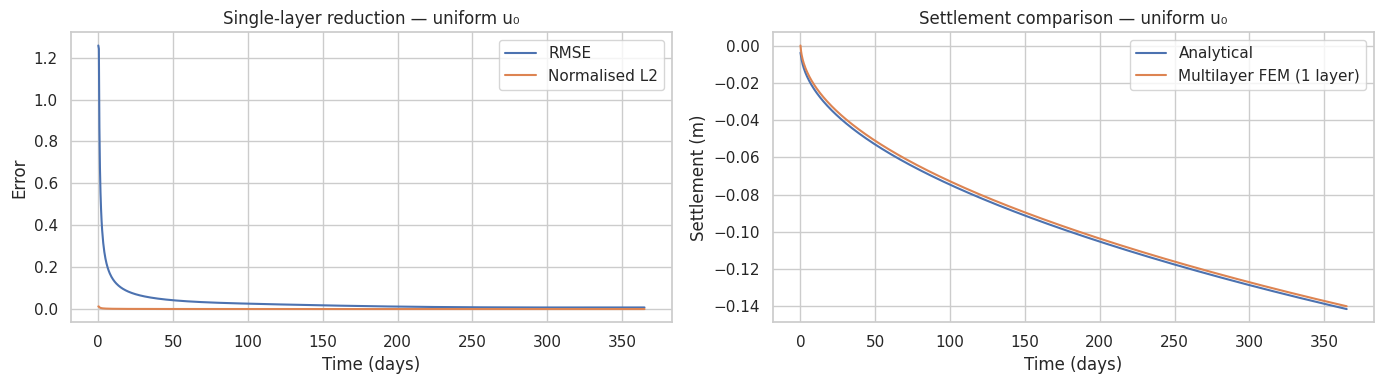

In [22]:
fem_s_u, fem_u_u, _ = Get_terzaghi1dMultilayer_FEA(
    depths, num, load, T, time_steps, Cv, Mv, Base=base, U0=True
)
an_c_u, an_u_u, depth_u, time_u = Get_terzaghi1d_Analytical(
    H, num, load, T, time_steps, Cv[0], N_terms
)

error_u  = fem_u_u - an_u_u
rmse_u   = np.sqrt((error_u**2).mean(axis=1))
norm_l2_u = np.sqrt((error_u**2).sum(axis=1) / ((an_u_u**2).sum(axis=1) + 1e-12))
total_s   = Mv[0] * load * H
an_s_u    = an_c_u.mean(axis=1) * total_s

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(time_days, rmse_u,    label="RMSE")
axes[0].plot(time_days, norm_l2_u, label="Normalised L2")
axes[0].set_xlabel("Time (days)")
axes[0].set_ylabel("Error")
axes[0].set_title("Single-layer reduction — uniform u₀")
axes[0].legend()

axes[1].plot(time_days, -an_s_u,   label="Analytical")
axes[1].plot(time_days, -fem_s_u,  label="Multilayer FEM (1 layer)")
axes[1].set_xlabel("Time (days)")
axes[1].set_ylabel("Settlement (m)")
axes[1].set_title("Settlement comparison — uniform u₀")
axes[1].legend()
plt.tight_layout()
plt.show()

## Reduction Test 2 — Boussinesq Initial Condition

The FEM initial field is used directly as u₀(z) for the arbitrary-u₀ analytical solver. Errors confirm that the two models are consistent for the same initial condition.


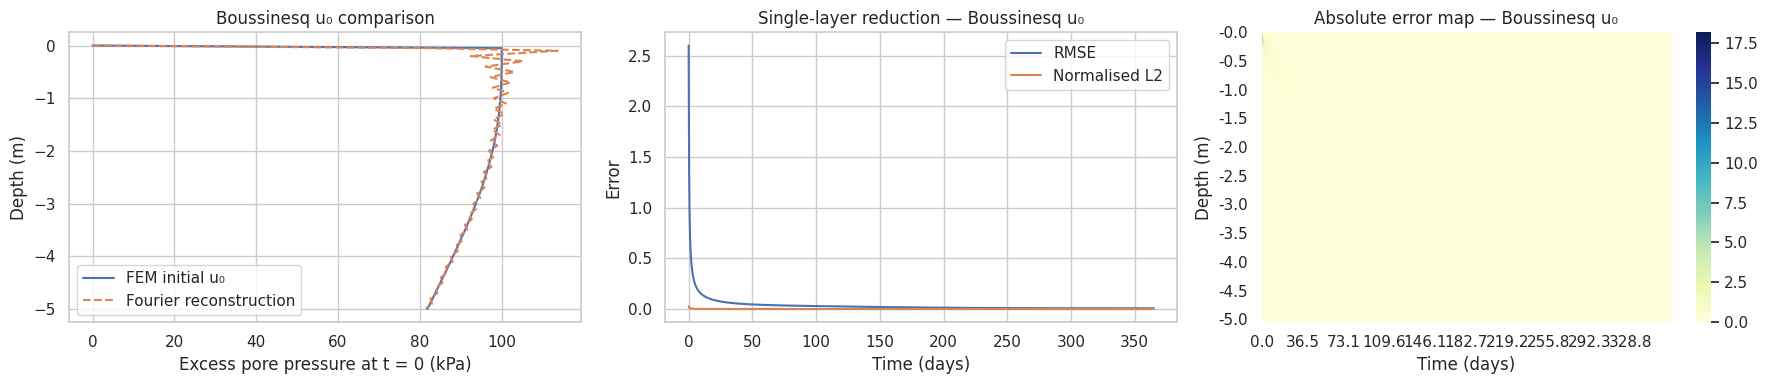

In [23]:
N_terms_b   = max(3, nodes // 2)
fem_s_b, fem_u_b, _ = Get_terzaghi1dMultilayer_FEA(
    depths, num, load, T, time_steps, Cv, Mv, Base=base, U0=False
)
u0_b = fem_u_b[0, :]
an_u_b, depth_b, time_b = Get_terzaghi1d_Analytical_u0(
    u0_b, H, num, T, time_steps, Cv[0], N_terms_b
)

error_b   = fem_u_b - an_u_b
rmse_b    = np.sqrt((error_b**2).mean(axis=1))
norm_l2_b = np.sqrt((error_b**2).sum(axis=1) / ((an_u_b**2).sum(axis=1) + 1e-12))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(u0_b,        z, label="FEM initial u₀")
axes[0].plot(an_u_b[0,:], z, "--", label="Fourier reconstruction")
axes[0].set_xlabel("Excess pore pressure at t = 0 (kPa)")
axes[0].set_ylabel("Depth (m)")
axes[0].set_title("Boussinesq u₀ comparison")
axes[0].legend()

axes[1].plot(time_b, rmse_b,    label="RMSE")
axes[1].plot(time_b, norm_l2_b, label="Normalised L2")
axes[1].set_xlabel("Time (days)")
axes[1].set_ylabel("Error")
axes[1].set_title("Single-layer reduction — Boussinesq u₀")
axes[1].legend()

kx = max(1, len(time_b) // 10)
ky = max(1, len(z)      // 10)
sns.heatmap(
    np.abs(error_b).T, annot=False, cmap="YlGnBu",
    xticklabels=time_b, yticklabels=z, ax=axes[2]
)
axes[2].set_xticks(np.arange(0, len(time_b), kx) + 0.5)
axes[2].set_xticklabels([f"{time_b[i]:.1f}" for i in range(0, len(time_b), kx)], rotation=0)
axes[2].set_yticks(np.arange(0, len(z), ky) + 0.5)
axes[2].set_yticklabels([f"{z[i]:.1f}" for i in range(0, len(z), ky)], rotation=0)
axes[2].set_xlabel("Time (days)")
axes[2].set_ylabel("Depth (m)")
axes[2].set_title("Absolute error map — Boussinesq u₀")
plt.tight_layout()
plt.show()

## Interface Pore-Pressure Continuity

A two-layer profile with a 4:1 Cv ratio is used. Pore pressure must be continuous across the interface (z = 2.5 m) at all times — there should be no step or kink in u.

The permeability of each layer:

```
k = Cv · Mv · γw
```


Two-layer profile:
  Layer 1: Cv = 5.00e-07 m²/s   Mv = 5.00e-04 m²/kN   k = 2.45e-09 m/s
  Layer 2: Cv = 7.00e-07 m²/s   Mv = 5.00e-04 m²/kN   k = 3.43e-09 m/s

Interface node index: 50   (z = 2.5000 m)


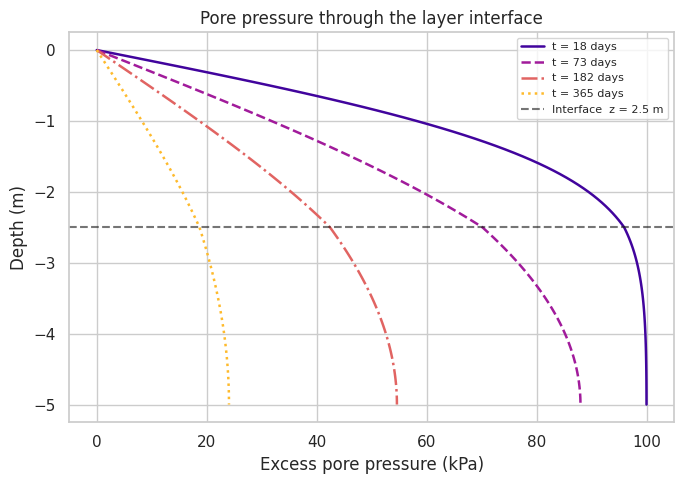

In [24]:
# Two-layer setup — large property contrast so the interface effect is visible
depths_2L = [2.5, 5.0]          # interface at 2.5 m
Cv_2L     = [5e-7, 7e-7]        # different Cv values
Mv_2L     = [5e-4, 5e-4]        # different Mv values, so Cv·du/dz need not be continuous
H_2L      = max(depths_2L)
z_2L      = np.linspace(0, H_2L, num + 1)
dz        = z_2L[1] - z_2L[0]

# Permeability per layer
k_2L = [Cv_2L[i] * Mv_2L[i] * gamma_w for i in range(2)]
print("Two-layer profile:")
for i in range(2):
    print(f"  Layer {i+1}: Cv = {Cv_2L[i]:.2e} m²/s   Mv = {Mv_2L[i]:.2e} m²/kN   k = {k_2L[i]:.2e} m/s")

_, u_2L, _ = Get_terzaghi1dMultilayer_FEA(
    depths_2L, num, load, T, time_steps, Cv_2L, Mv_2L, Base=base, U0=True
)

interface_z = depths_2L[0]   # 2.5 m
idx = np.argmin(np.abs(z_2L - interface_z))
print(f"\nInterface node index: {idx}   (z = {z_2L[idx]:.4f} m)")

# Pore-pressure profiles through the interface at several times
fig, ax = plt.subplots(figsize=(7, 5))
linestyles = ["-", "--", "-.", ":"]
fracs      = [0.05, 0.2, 0.5, 1.0]
colours    = plt.cm.plasma(np.linspace(0.1, 0.85, len(fracs)))
for ls, col, frac in zip(linestyles, colours, fracs):
    ti    = int(frac * (time_steps - 1))
    label = f"t = {time_days[ti]:.0f} days"
    ax.plot(u_2L[ti, :], -z_2L, color=col, linestyle=ls, linewidth=1.8, label=label)
ax.axhline(-interface_z, color="k", linewidth=1.5, linestyle="--", alpha=0.6,
           label=f"Interface  z = {interface_z} m")
ax.set_xlabel("Excess pore pressure (kPa)")
ax.set_ylabel("Depth (m)")
ax.set_title("Pore pressure through the layer interface")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Darcy Flux Continuity

For layered consolidation, the physically meaningful interface quantity is the Darcy flux

```
q = -(k / γw) · ∂u/∂z
```

If `Mv` differs between layers, neither `Cv` nor `∂u/∂z` should be expected to be continuous on their own, because `k = Cv · Mv · γw` changes with both parameters. The check below therefore looks directly at the one-sided Darcy flux above and below the interface at 6 months and 1 year.


At interface  z = 2.5 m,  t = 50.1 days
Pore pressure:
  u (node above)    = 77.9084 kPa
  u (interface)     = 78.9172 kPa
  u (node below)    = 79.6195 kPa
Darcy flux  q = -(k/γw) · ∂u/∂z:
  q above interface = -5.043753e-09 m/s
  q below interface = -4.915999e-09 m/s
  Relative difference = 2.533%

At interface  z = 2.5 m,  t = 365.0 days
Pore pressure:
  u (node above)    = 18.3831 kPa
  u (interface)     = 18.6743 kPa
  u (node below)    = 18.8789 kPa
Darcy flux  q = -(k/γw) · ∂u/∂z:
  q above interface = -1.456309e-09 m/s
  q below interface = -1.432056e-09 m/s
  Relative difference = 1.665%



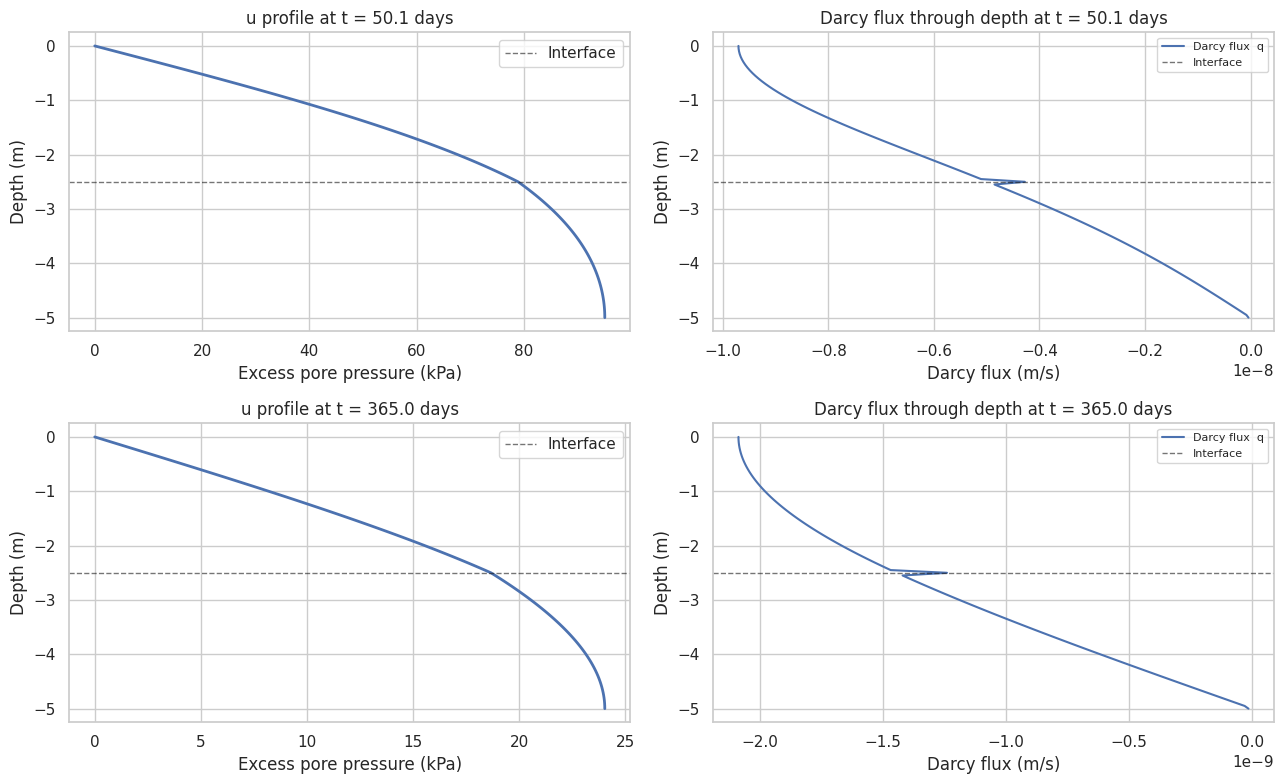

In [25]:
check_days = [50, 365.0]

def relative_difference(a, b):
    scale = max(abs(a), abs(b), 1e-30)
    return abs(a - b) / scale * 100.0

fig, axes = plt.subplots(len(check_days), 2, figsize=(13, 4 * len(check_days)), squeeze=False)

for row, target_day in enumerate(check_days):
    t_check = int(np.argmin(np.abs(time_days - target_day)))
    u_t = u_2L[t_check, :]

    grad_above = (u_t[idx]     - u_t[idx - 1]) / dz
    grad_below = (u_t[idx + 1] - u_t[idx])     / dz

    darcy_above = -(k_2L[0] / gamma_w) * grad_above
    darcy_below = -(k_2L[1] / gamma_w) * grad_below
    darcy_rel_diff = relative_difference(darcy_above, darcy_below)

    print(f"At interface  z = {interface_z} m,  t = {time_days[t_check]:.1f} days")
    print("Pore pressure:")
    print(f"  u (node above)    = {u_t[idx-1]:.4f} kPa")
    print(f"  u (interface)     = {u_t[idx]:.4f} kPa")
    print(f"  u (node below)    = {u_t[idx+1]:.4f} kPa")
    print("Darcy flux  q = -(k/γw) · ∂u/∂z:")
    print(f"  q above interface = {darcy_above:.6e} m/s")
    print(f"  q below interface = {darcy_below:.6e} m/s")
    print(f"  Relative difference = {darcy_rel_diff:.3f}%\n")

    axes[row, 0].plot(u_t, -z_2L, linewidth=2)
    axes[row, 0].axhline(-interface_z, color="k", linestyle="--", linewidth=1, alpha=0.6, label="Interface")
    axes[row, 0].set_xlabel("Excess pore pressure (kPa)")
    axes[row, 0].set_ylabel("Depth (m)")
    axes[row, 0].set_title(f"u profile at t = {time_days[t_check]:.1f} days")
    axes[row, 0].legend()

    grad = np.gradient(u_t, z_2L)
    darcy_flux = -np.where(z_2L <= interface_z, k_2L[0] / gamma_w, k_2L[1] / gamma_w) * grad
    axes[row, 1].plot(darcy_flux, -z_2L, label="Darcy flux  q")
    axes[row, 1].axhline(-interface_z, color="k", linestyle="--", linewidth=1, alpha=0.6, label="Interface")
    axes[row, 1].set_xlabel("Darcy flux (m/s)")
    axes[row, 1].set_ylabel("Depth (m)")
    axes[row, 1].set_title(f"Darcy flux through depth at t = {time_days[t_check]:.1f} days")
    axes[row, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()